<a href="https://colab.research.google.com/github/Aavani142/Loan_Approval_PredictionML/blob/main/Loan_Approval_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving loan_approval_dataset.csv to loan_approval_dataset (1).csv


In [ ]:
df = pd.read_csv("loan_approval_dataset.csv")

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (4269, 13)

Column Names:
['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  42

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 0


In [ ]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [ ]:
print(df['loan_status'].value_counts())

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


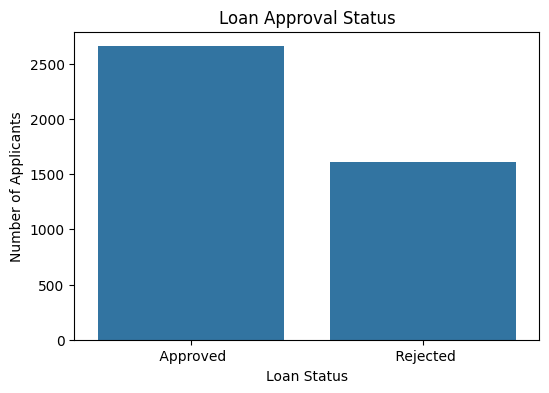

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x='loan_status', data=df)

plt.title('Loan Approval Status')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applicants')

plt.show()

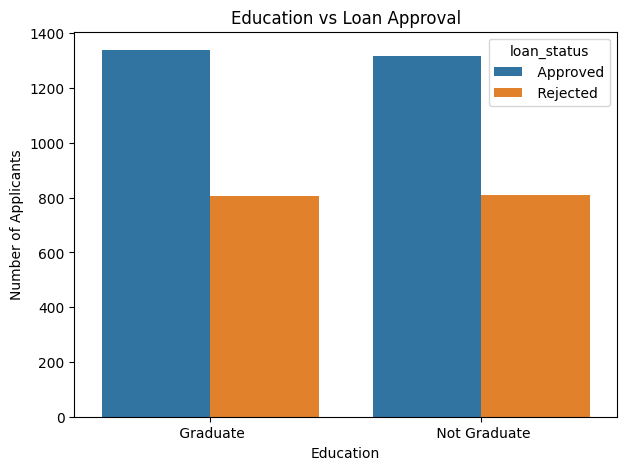

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x='education',
    hue='loan_status',
    data=df
)

plt.title('Education vs Loan Approval')
plt.xlabel('Education')
plt.ylabel('Number of Applicants')

plt.show()

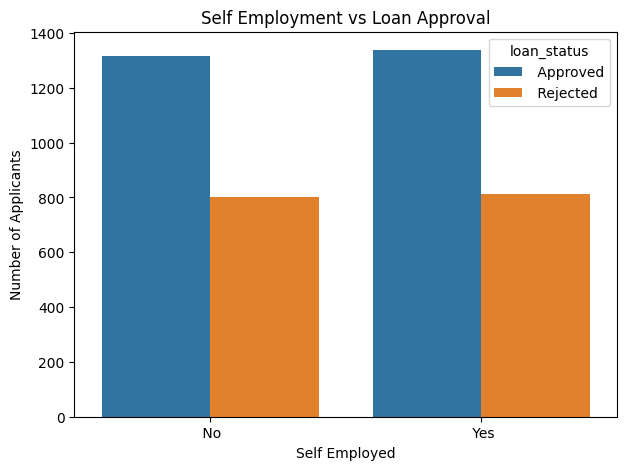

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x='self_employed',
    hue='loan_status',
    data=df
)

plt.title('Self Employment vs Loan Approval')
plt.xlabel('Self Employed')
plt.ylabel('Number of Applicants')

plt.show()

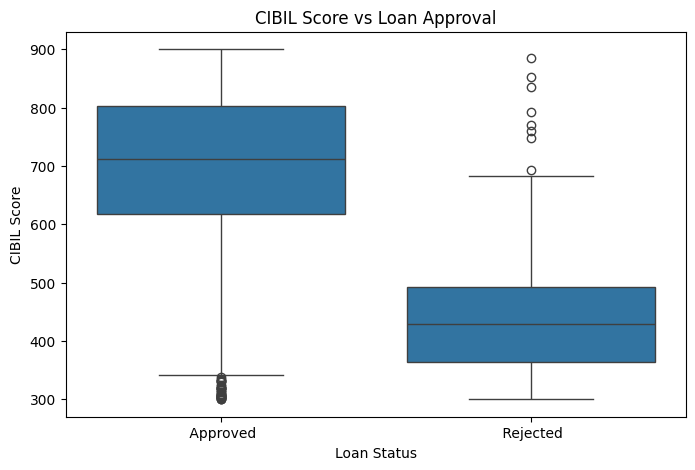

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='loan_status',
    y='cibil_score',
    data=df
)

plt.title('CIBIL Score vs Loan Approval')
plt.xlabel('Loan Status')
plt.ylabel('CIBIL Score')

plt.show()

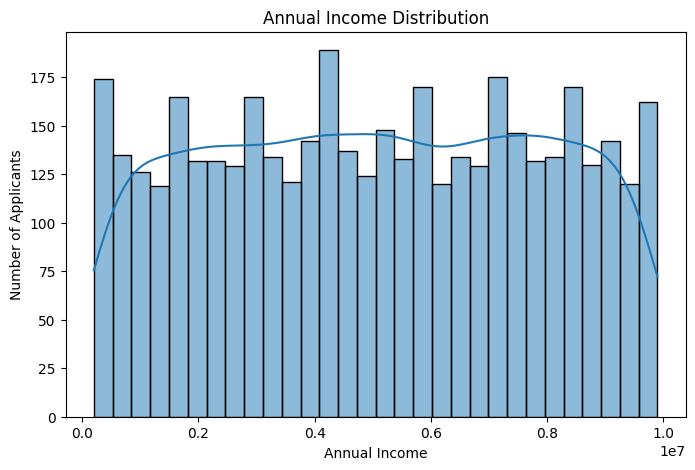

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['income_annum'],
    bins=30,
    kde=True
)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income')
plt.ylabel('Number of Applicants')

plt.show()

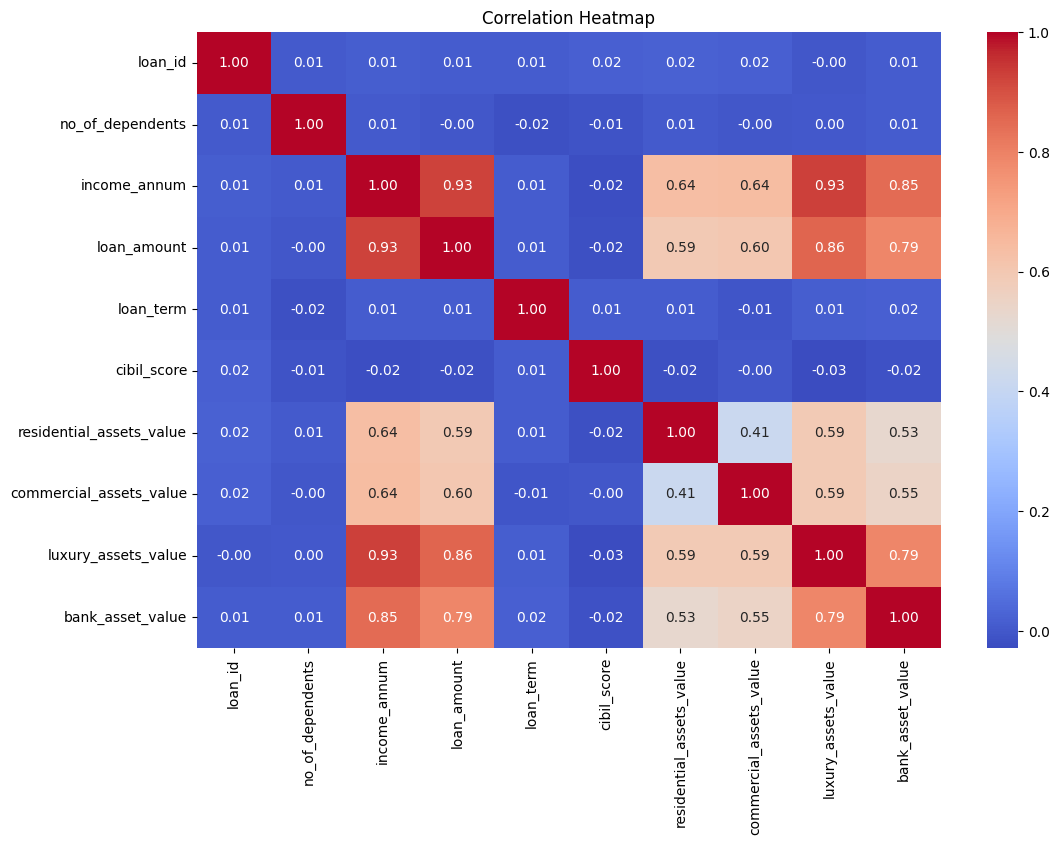

In [ ]:
plt.figure(figsize=(12, 8))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [ ]:
X = df.drop(['loan_id', 'loan_status'], axis=1)
y = df['loan_status']

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

Features (X):
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

Target (y):
loan_status


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3415, 11)
Testing data: (854, 11)


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Predictions completed successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions completed successfully!
First 10 predictions: [1 0 1 0 0 0 0 1 0 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.7985948477751756
Model Accuracy (%): 79.85948477751757


In [ ]:
print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       536
           1       0.80      0.61      0.69       318

    accuracy                           0.80       854
   macro avg       0.80      0.76      0.77       854
weighted avg       0.80      0.80      0.79       854



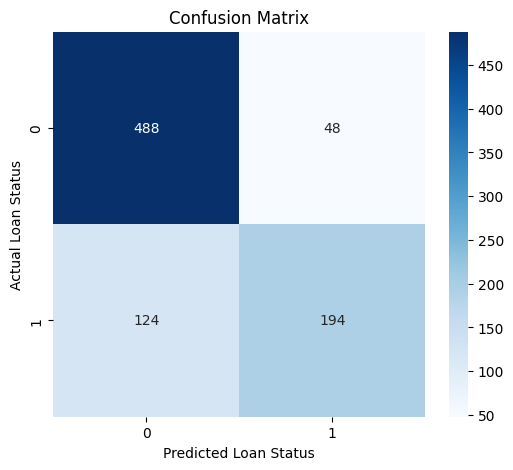

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Loan Status')
plt.ylabel('Actual Loan Status')

plt.show()

In [ ]:
new_applicant = X_test.iloc[[0]]

prediction = model.predict(new_applicant)

if prediction[0] == 1:
    print("Loan Status: Approved")
else:
    print("Loan Status: Rejected")

Loan Status: Approved


In [ ]:
print("===== LOAN APPROVAL PREDICTION RESULTS =====")
print("Model Used: Logistic Regression")
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

===== LOAN APPROVAL PREDICTION RESULTS =====
Model Used: Logistic Regression
Accuracy: 79.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       536
           1       0.80      0.61      0.69       318

    accuracy                           0.80       854
   macro avg       0.80      0.76      0.77       854
weighted avg       0.80      0.80      0.79       854

